# Notebook 03 · Exploratory Data Analysis  



## 0 · Imports & config

In [5]:
import gc, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pyarrow.dataset as ds
import psutil, pickle

warnings.filterwarnings("ignore")

# CẤU HÌNH HIỂN THỊ PANDAS
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# GIAO DIỆN BIỂU ĐỒ (PLOT STYLE)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
FIGSIZE  = (12, 5)
COLOR_PRIMARY   = "#4C72B0"
COLOR_SECONDARY = "#DD8452"

# QUẢN LÝ ĐƯỜNG DẪN (PATHS)
CLEANED_DIR = Path(r"D:\mmd\data\cleaned")
FIGURES_DIR = Path(r"D:\mmd\outputs\figures")

# Tự động tạo thư mục chứa ảnh nếu chưa tồn tại
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# CÁC HÀM TIỆN ÍCH

def savefig(name): 
    """Lưu và hiển thị biểu đồ hiện tại"""
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {FIGURES_DIR/name}.png")

def ram(): 
    """Trả về chuỗi text báo cáo tình trạng sử dụng RAM hiện tại"""
    v = psutil.virtual_memory()
    return f"RAM {v.used/1e9:.1f}/{v.total/1e9:.1f} GB ({v.percent:.0f}%)"

# KHỞI CHẠY & KIỂM TRA
print(f"Figures dir: {FIGURES_DIR}")
print(ram())

Figures dir: D:\mmd\outputs\figures
RAM 12.2/16.9 GB (72%)


In [6]:
gc.collect()

1098

In [7]:
ram()

'RAM 12.2/16.9 GB (72%)'

## 1 · Load cleaned data

In [9]:
import pyarrow.parquet as pq
import pyarrow.dataset as ds

# KHAI BÁO ĐƯỜNG DẪN TỆP DỮ LIỆU
REVIEW_FILE  = CLEANED_DIR / "reviews_clean.parquet"
META_FILE    = CLEANED_DIR / "meta_clean.parquet"
SESSION_FILE = CLEANED_DIR / "sessions.pkl"

# KIỂM TRA SCHEMA TRƯỚC KHI TẢI (TỐI ƯU RAM)
review_schema = pq.read_schema(REVIEW_FILE)
meta_schema   = pq.read_schema(META_FILE)

print("Review columns :", review_schema.names)
print("Meta    columns:", meta_schema.names)

# 1. TẢI DỮ LIỆU SESSIONS (Từ file Pickle)
with open(SESSION_FILE, "rb") as f:
    sessions = pickle.load(f)

print(f"Sessions: {len(sessions):,} users")
print(f"Session columns: {sessions.columns.tolist()}")

# 2. TẢI DỮ LIỆU REVIEWS (Từ file Parquet)
# Chỉ lấy những cột thực sự cần thiết cho quá trình EDA
REVIEW_COLS_FULL = ["user_idx", "item_idx", "rating", "timestamp"]

df = pd.read_parquet(REVIEW_FILE, columns=REVIEW_COLS_FULL, engine="pyarrow")

# Ép kiểu dữ liệu (Downcasting) để giảm dung lượng lưu trữ trên RAM
df["user_idx"]  = df["user_idx"].astype("int32")
df["item_idx"]  = df["item_idx"].astype("int32")
df["rating"]    = df["rating"].astype("float32")
df["timestamp"] = df["timestamp"].astype("int64")

print(f"\nReviews : {len(df):,} rows  |  {df.columns.tolist()}")

# 3. TẢI DỮ LIỆU META (Từ file Parquet)
META_COLS_USE = ["item_idx", "average_rating", "rating_number", "price_usd", "store"]

META_COLS_USE = [c for c in META_COLS_USE if c in meta_schema.names]

df_meta = pd.read_parquet(META_FILE, columns=META_COLS_USE, engine="pyarrow")
df_meta["item_idx"] = df_meta["item_idx"].astype("int32")

print(f"Meta    : {len(df_meta):,} rows  |  {df_meta.columns.tolist()}")

# KIỂM TRA KIỂU DỮ LIỆU & BỘ NHỚ CUỐI CÙNG
print("\nReviews dtypes:")
print(df.dtypes)
print(ram())

Review columns : ['user_idx', 'user_id', 'item_idx', 'parent_asin', 'rating', 'timestamp', 'dt']
Meta    columns: ['parent_asin', 'title', 'main_category', 'average_rating', 'rating_number', 'store', 'price_usd', 'item_idx']
Sessions: 2,712,338 users
Session columns: ['user_idx', 'train_seq', 'val_item', 'test_item', 'seq_len']

Reviews : 24,930,015 rows  |  ['user_idx', 'item_idx', 'rating', 'timestamp']
Meta    : 667,277 rows  |  ['item_idx', 'average_rating', 'rating_number', 'price_usd', 'store']

Reviews dtypes:
user_idx       int32
item_idx       int32
rating       float32
timestamp      int64
dtype: object
RAM 14.4/16.9 GB (85%)


## 2 · Rating Distribution

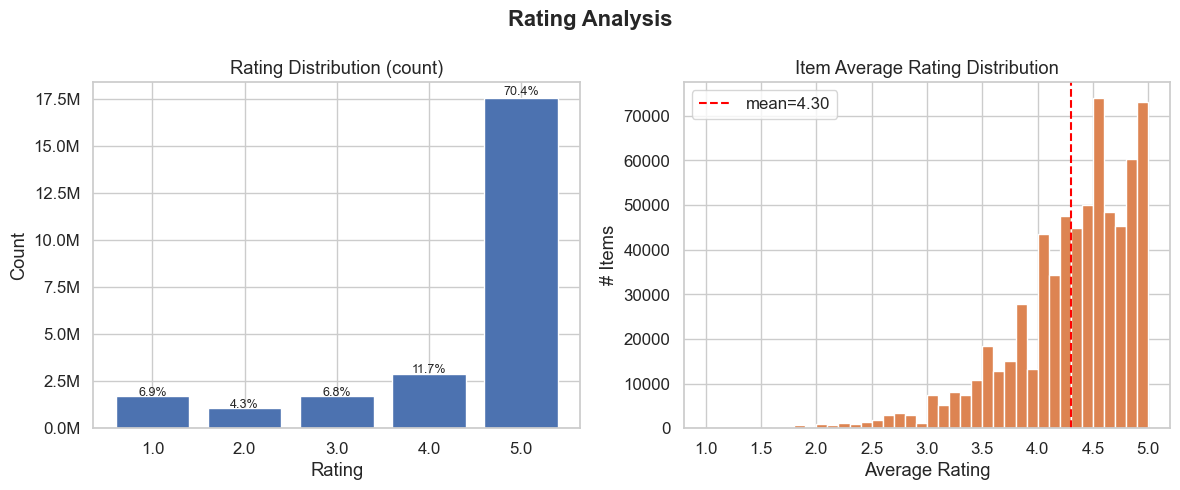

  Saved → D:\mmd\outputs\figures\01_rating_distribution.png
Overall mean rating : 4.343
% 5-star reviews    : 70.4%
% 1-star reviews    : 6.9%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# BIỂU ĐỒ 1: PHÂN BỐ SỐ LƯỢNG ĐÁNH GIÁ (COUNT PER RATING)
rating_vc = df["rating"].value_counts().sort_index()

axes[0].bar(rating_vc.index.astype(str), rating_vc.values, color=COLOR_PRIMARY, edgecolor="white")
axes[0].set_title("Rating Distribution (count)")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")


axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

for i, (r, c) in enumerate(rating_vc.items()):
    # c + c*0.01 giúp đẩy text lên trên đỉnh cột một khoảng nhỏ để chữ không bị lẹm vào đồ thị
    axes[0].text(i, c + c*0.01, f"{c/len(df)*100:.1f}%", ha="center", fontsize=9)


# BIỂU ĐỒ 2: TRUNG BÌNH RATING CỦA TỪNG SẢN PHẨM (AVG RATING PER ITEM)
item_avg = df.groupby("item_idx")["rating"].mean()

axes[1].hist(item_avg, bins=40, color=COLOR_SECONDARY, edgecolor="white")
axes[1].set_title("Item Average Rating Distribution")
axes[1].set_xlabel("Average Rating")
axes[1].set_ylabel("# Items")

# Vẽ thêm một đường gạch đứt (--) màu đỏ thẳng đứng để thể hiện điểm trung bình của toàn bộ dataset
axes[1].axvline(item_avg.mean(), color="red", ls="--", lw=1.5, label=f"mean={item_avg.mean():.2f}")
axes[1].legend()


# LƯU BIỂU ĐỒ & IN KẾT QUẢ THỐNG KÊ
plt.suptitle("Rating Analysis", fontweight="bold")

savefig("01_rating_distribution")

print(f"Overall mean rating : {df['rating'].mean():.3f}")
print(f"% 5-star reviews    : {(df['rating']==5).mean()*100:.1f}%")
print(f"% 1-star reviews    : {(df['rating']==1).mean()*100:.1f}%")

## 3 · User & Item Activity (Long-tail)

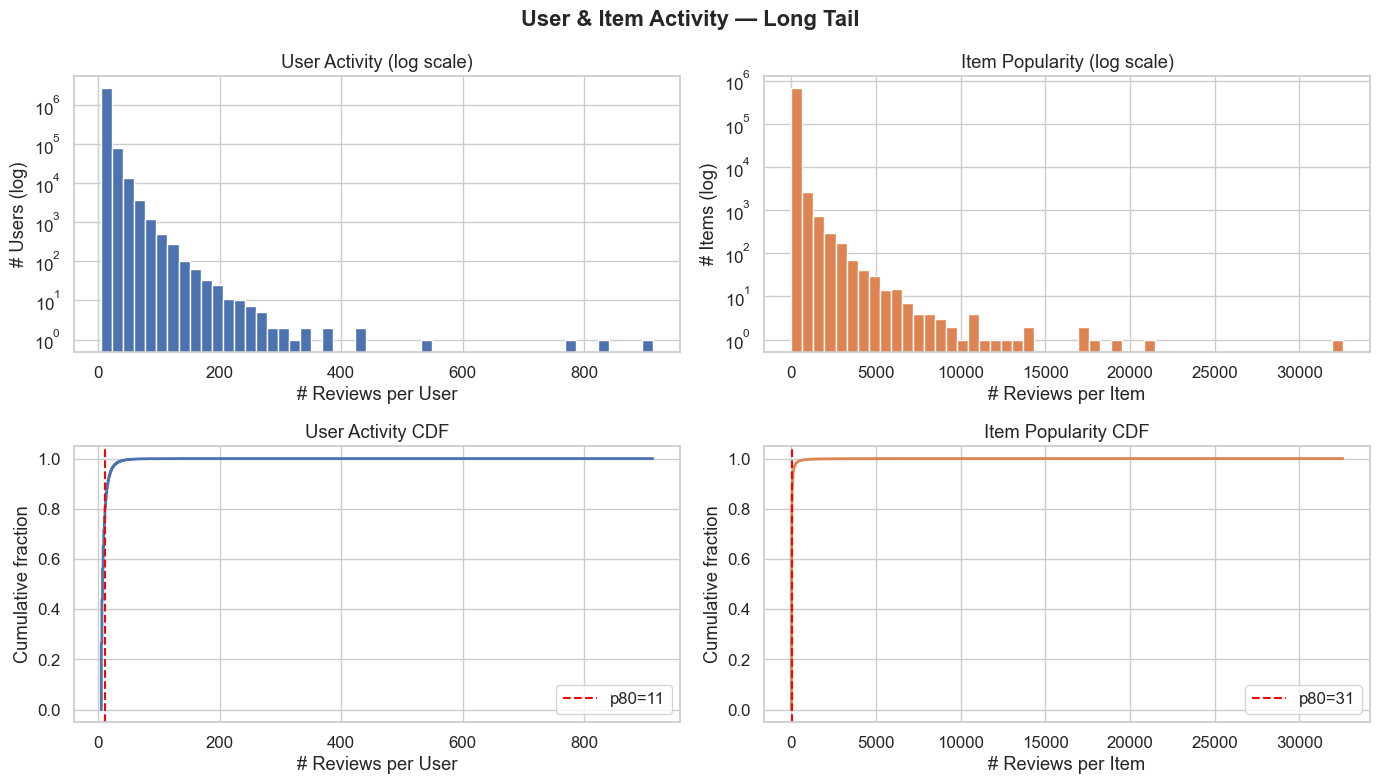

  Saved → D:\mmd\outputs\figures\02_long_tail.png
User activity stats:
count   2712338.0000
mean          9.1913
std           7.0218
min           5.0000
25%           5.0000
50%           7.0000
75%          10.0000
max         913.0000

Item popularity stats:
count   667277.0000
mean        37.3608
std        162.9622
min          5.0000
25%          7.0000
50%         11.0000
75%         24.0000
max      32576.0000

Top 20% popular items cover 76.2% of all interactions (long-tail: 0.76)


In [15]:
user_counts = df["user_idx"].value_counts()
item_counts = df["item_idx"].value_counts()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# BIỂU ĐỒ [0, 0]: HISTOGRAM HOẠT ĐỘNG CỦA USER
# Dùng thang đo log (log=True) vì dữ liệu này có dạng đuôi dài (Long-tail): 
# Đa số người dùng chỉ đánh giá 1-2 lần, rất ít người đánh giá hàng trăm lần.
axes[0,0].hist(user_counts.values, bins=50, log=True, color=COLOR_PRIMARY, edgecolor="white")
axes[0,0].set_title("User Activity (log scale)")
axes[0,0].set_xlabel("# Reviews per User")
axes[0,0].set_ylabel("# Users (log)")

# BIỂU ĐỒ [0, 1]: HISTOGRAM ĐỘ PHỔ BIẾN CỦA ITEM
# Phân phối lượt đánh giá cho từng sản phẩm (Item Popularity)
axes[0,1].hist(item_counts.values, bins=50, log=True, color=COLOR_SECONDARY, edgecolor="white")
axes[0,1].set_title("Item Popularity (log scale)")
axes[0,1].set_xlabel("# Reviews per Item")
axes[0,1].set_ylabel("# Items (log)")

# BIỂU ĐỒ [1, 0]: CUMULATIVE DISTRIBUTION FUNCTION (CDF) CỦA USER
# Sắp xếp và tính CDF để xem phần lớn users tập trung ở mốc bao nhiêu đánh giá
sorted_u = np.sort(user_counts.values)
cdf_u    = np.arange(1, len(sorted_u)+1) / len(sorted_u)

axes[1,0].plot(sorted_u, cdf_u, color=COLOR_PRIMARY, lw=2)
axes[1,0].set_title("User Activity CDF")
axes[1,0].set_xlabel("# Reviews per User")
axes[1,0].set_ylabel("Cumulative fraction")

# Vẽ vạch đỏ ở Percentile 80 (Cho biết 80% người dùng đánh giá <= mốc này)
axes[1,0].axvline(np.percentile(sorted_u, 80), color="red", ls="--",
                   label=f"p80={np.percentile(sorted_u, 80):.0f}")
axes[1,0].legend()

# BIỂU ĐỒ [1, 1]: CDF ĐỘ PHỔ BIẾN CỦA ITEM
sorted_i = np.sort(item_counts.values)
cdf_i    = np.arange(1, len(sorted_i)+1) / len(sorted_i)

axes[1,1].plot(sorted_i, cdf_i, color=COLOR_SECONDARY, lw=2)
axes[1,1].set_title("Item Popularity CDF")
axes[1,1].set_xlabel("# Reviews per Item")
axes[1,1].set_ylabel("Cumulative fraction")

# Vẽ vạch đỏ ở Percentile 80 (Cho biết 80% sản phẩm nhận được <= mốc đánh giá này)
axes[1,1].axvline(np.percentile(sorted_i, 80), color="red", ls="--",
                   label=f"p80={np.percentile(sorted_i, 80):.0f}")
axes[1,1].legend()

# LƯU BIỂU ĐỒ & IN TÓM TẮT THỐNG KÊ
plt.suptitle("User & Item Activity — Long Tail", fontweight="bold")
savefig("02_long_tail")

# In bảng thống kê tổng quan (mean, std, min, max, tứ phân vị)
print("User activity stats:")
print(user_counts.describe().to_string())

print("\nItem popularity stats:")
print(item_counts.describe().to_string())

# TÍNH TOÁN QUY LUẬT PARETO (80/20) CHO LONG-TAIL
# Trả lời câu hỏi: Top 20% sản phẩm phổ biến nhất chiếm bao nhiêu % tổng số lượt tương tác?
top20_items = item_counts.nlargest(int(len(item_counts) * 0.2))
coverage = top20_items.sum() / len(df)

print(f"\nTop 20% popular items cover {coverage*100:.1f}% of all interactions (long-tail: {coverage:.2f})")

## 4 · Session Length Distribution

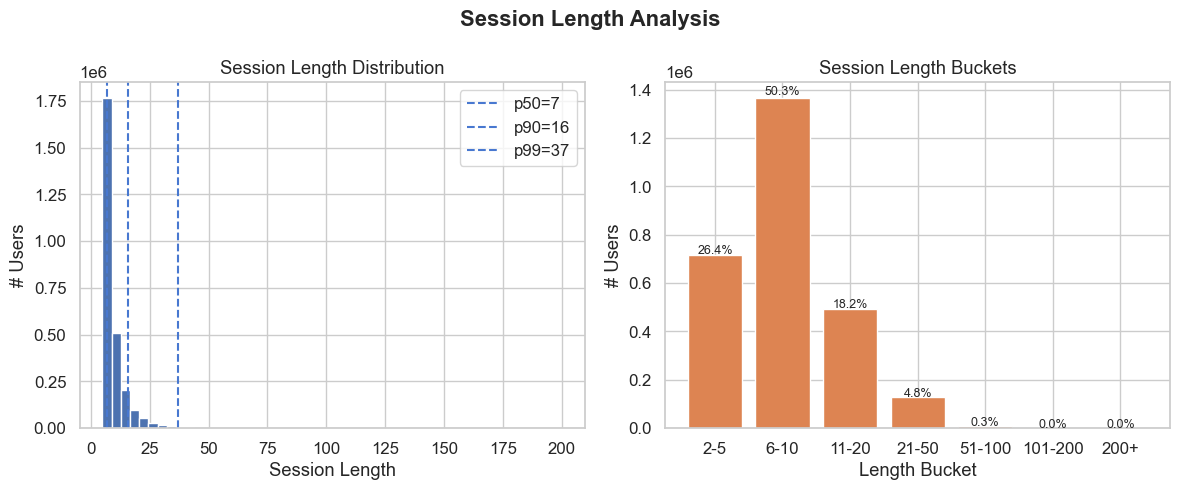

  Saved → D:\mmd\outputs\figures\03_session_length.png
Session length statistics:
count   2712338.0000
mean          9.1895
std           6.9271
min           5.0000
25%           5.0000
50%           7.0000
75%          10.0000
max         200.0000

→ Recommended max_seq_len for GRU4Rec: 21 (p95)


In [16]:
seq_lens = sessions["seq_len"]

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# BIỂU ĐỒ 1: HISTOGRAM PHÂN BỐ ĐỘ DÀI SESSION
# Vẽ biểu đồ phân bố tần suất (Histogram) chia thành 50 khoảng (bins)
axes[0].hist(seq_lens, bins=50, color=COLOR_PRIMARY, edgecolor="white")
axes[0].set_title("Session Length Distribution")
axes[0].set_xlabel("Session Length")
axes[0].set_ylabel("# Users")

# Thêm các đường kẻ dọc (vertical lines) để biểu diễn các mốc phân vị (Percentiles)
# p50 (Trung vị), p90, và p99 giúp ta thấy rõ độ dài tối đa mà phần lớn user đạt được
for p, lbl in [(50, "p50"), (90, "p90"), (99, "p99")]:
    val = np.percentile(seq_lens, p)
    axes[0].axvline(val, ls="--", lw=1.5, label=f"{lbl}={val:.0f}")
axes[0].legend()

# BIỂU ĐỒ 2: CHIA NHÓM ĐỘ DÀI (BUCKETING)
# pd.cut giúp phân loại dữ liệu liên tục thành các nhóm rời rạc (categorical)
buckets = pd.cut(
    seq_lens, 
    bins=[0, 5, 10, 20, 50, 100, 200, 10000],
    labels=["2-5", "6-10", "11-20", "21-50", "51-100", "101-200", "200+"]
)

# Đếm số lượng user rơi vào từng nhóm và sắp xếp lại theo thứ tự bins
bucket_counts = buckets.value_counts().sort_index()

# Vẽ biểu đồ cột cho các nhóm độ dài
axes[1].bar(bucket_counts.index.astype(str), bucket_counts.values,
            color=COLOR_SECONDARY, edgecolor="white")
axes[1].set_title("Session Length Buckets")
axes[1].set_xlabel("Length Bucket")
axes[1].set_ylabel("# Users")

# Ghi phần trăm lên trên đỉnh mỗi cột
for i, v in enumerate(bucket_counts.values):
    axes[1].text(i, v + v*0.01, f"{v/len(seq_lens)*100:.1f}%", ha="center", fontsize=9)

# LƯU BIỂU ĐỒ & IN TÓM TẮT THỐNG KÊ
plt.suptitle("Session Length Analysis", fontweight="bold")
savefig("03_session_length")

# In ra các chỉ số thống kê cơ bản
print("Session length statistics:")
print(seq_lens.describe().to_string())

# Đưa ra gợi ý về tham số max_seq_len (độ dài chuỗi tối đa) cho mô hình Học Sâu (VD: GRU4Rec, SASRec)
# Thông thường chọn mốc p95 hoặc p90 để cắt chuỗi (padding/truncation) giúp tiết kiệm RAM/VRAM khi train
p95_val = int(np.percentile(seq_lens, 95))
print(f"\n→ Recommended max_seq_len for GRU4Rec: {p95_val} (p95)")

## 5 · Temporal Patterns

Timestamp unit: ms


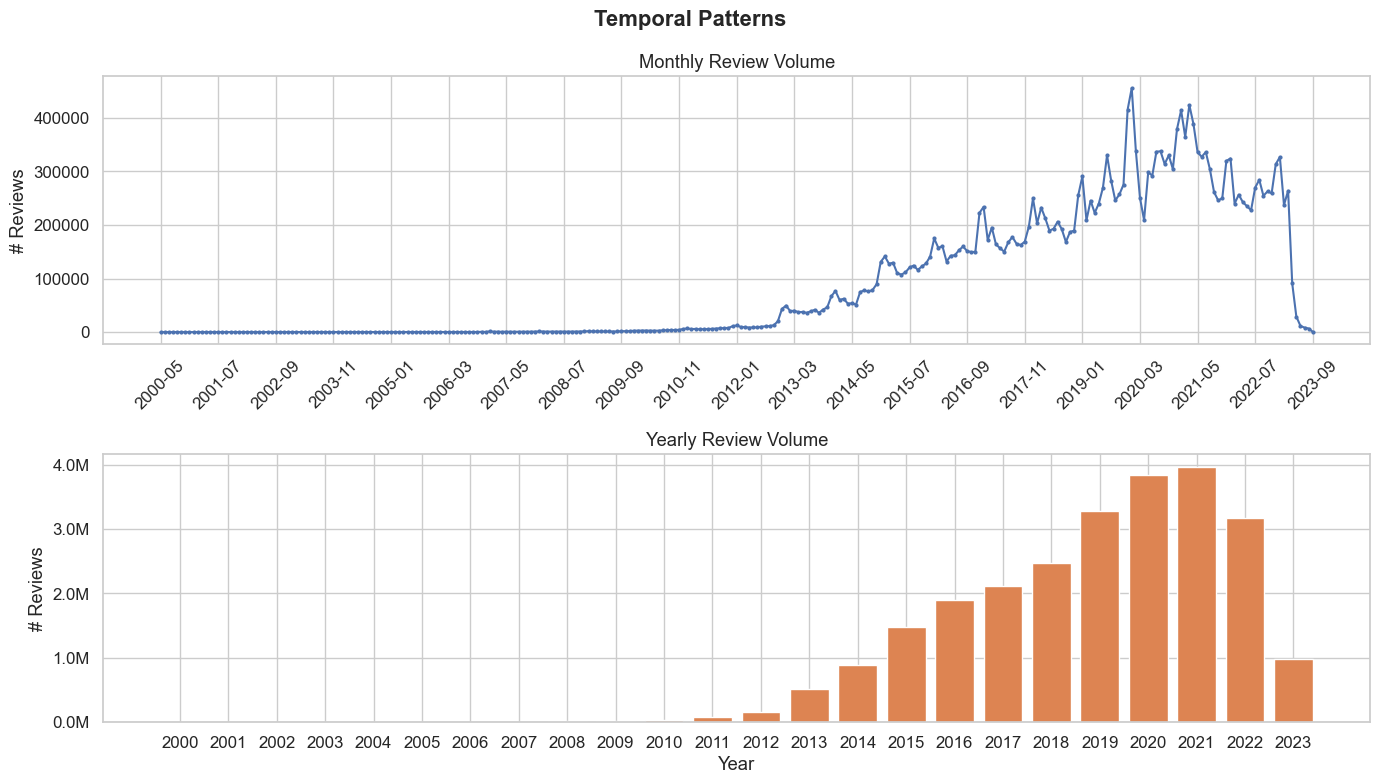

  Saved → D:\mmd\outputs\figures\04_temporal_patterns.png
Year-over-year growth:
  2001: +304.3%
  2002: +164.5%
  2003: +114.6%
  2004: +21.8%
  2005: +146.7%
  2006: +104.5%
  2007: +189.5%
  2008: +26.8%
  2009: +57.0%
  2010: +120.9%
  2011: +96.3%
  2012: +104.4%
  2013: +208.4%
  2014: +73.0%
  2015: +67.2%
  2016: +28.1%
  2017: +11.3%
  2018: +17.4%
  2019: +32.5%
  2020: +17.1%
  2021: +3.3%
  2022: -20.2%
  2023: -69.2%


In [17]:

# CHUẨN BỊ DỮ LIỆU THỜI GIAN
# Tự động nhận diện đơn vị của timestamp (giây - s hoặc mili-giây - ms) để quy đổi cho chính xác
TS_UNIT = "ms" if df["timestamp"].max() > 1_000_000_000_000 else "s"
print(f"Timestamp unit: {TS_UNIT}")

# Tạo cột datetime chuẩn và trích xuất chu kỳ năm-tháng (VD: 2023-01)
df["dt"] = pd.to_datetime(df["timestamp"], unit=TS_UNIT)
df["year_month"] = df["dt"].dt.to_period("M")

# Đếm số lượng review theo từng tháng
monthly = df.groupby("year_month").size().reset_index(name="count")
monthly["year_month_str"] = monthly["year_month"].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# BIỂU ĐỒ 1: KHỐI LƯỢNG REVIEW THEO TỪNG THÁNG
axes[0].plot(monthly["year_month_str"], monthly["count"],
             color=COLOR_PRIMARY, lw=1.5, marker="o", ms=2)
axes[0].set_title("Monthly Review Volume")
axes[0].set_ylabel("# Reviews")
axes[0].tick_params(axis="x", rotation=45)

# Hiển thị x-ticks giãn cách (bỏ qua một số tháng để trục X không bị chèn ép, rối mắt)
step = max(1, len(monthly) // 20)
axes[0].set_xticks(monthly["year_month_str"][::step])

# BIỂU ĐỒ 2: TỔNG KHỐI LƯỢNG REVIEW THEO NĂM
# Nhóm dữ liệu theo năm và đếm
yearly = df.groupby(df["dt"].dt.year).size()

axes[1].bar(yearly.index.astype(str), yearly.values,
            color=COLOR_SECONDARY, edgecolor="white")
axes[1].set_title("Yearly Review Volume")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("# Reviews")

# Định dạng trục Y theo đơn vị Triệu (M)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# LƯU BIỂU ĐỒ & IN CHỈ SỐ TĂNG TRƯỞNG
plt.suptitle("Temporal Patterns", fontweight="bold")
savefig("04_temporal_patterns")

# Tính tốc độ tăng trưởng YoY (Year-over-Year Growth Rate)
yoy = yearly.pct_change().dropna() * 100

print("Year-over-year growth:")
for yr, pct in yoy.items():
    print(f"  {yr}: {pct:+.1f}%")

## 6 · Cold-start Analysis

Total test samples       : 2,712,338
Cold-start test items    : 7,803
Cold-start ratio         : 0.29%


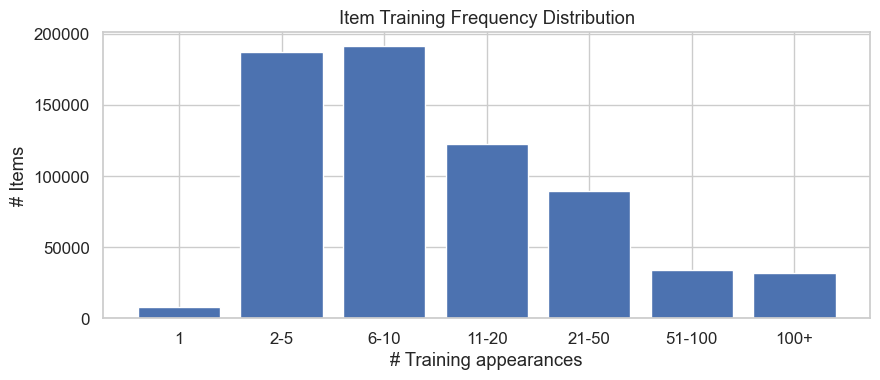

  Saved → D:\mmd\outputs\figures\05_item_frequency_bins.png


In [18]:

# PHÂN TÍCH VẤN ĐỀ COLD-START (SẢN PHẨM MỚI)
# Định nghĩa cold-start: Là những item chỉ xuất hiện trong tập kiểm thử (test set) 
# mà chưa từng xuất hiện trong tập huấn luyện (train set). 
# Mô hình sẽ rất khó dự đoán các item này vì chưa được học qua.
# Sau khi chia split theo phương pháp LOO (Leave-One-Out), 'train_seq' chứa các item trừ 2 item cuối.

# 1. Thu thập toàn bộ các item (sản phẩm) xuất hiện trong tập train
train_items = set()
for seq in sessions["train_seq"]:
    train_items.update(seq)

# 2. Lấy danh sách các item nằm trong tập test
test_items_all  = sessions["test_item"].values

# Lọc ra các sản phẩm cold-start (có trong test nhưng KHÔNG có trong train)
cold_test_items = [i for i in test_items_all if i not in train_items]

# Tính toán và in ra tỷ lệ Cold-start
cold_start_ratio = len(cold_test_items) / len(test_items_all)

print(f"Total test samples       : {len(test_items_all):,}")
print(f"Cold-start test items    : {len(cold_test_items):,}")
print(f"Cold-start ratio         : {cold_start_ratio*100:.2f}%")


# ĐẾM TẦN SUẤT XUẤT HIỆN CỦA TỪNG SẢN PHẨM
from collections import Counter

# Dùng thư viện Counter để đếm nhanh và chính xác tần suất xuất hiện của từng item trong train_seq
train_freq = Counter()
for seq in sessions["train_seq"]:
    train_freq.update(seq)

# CHIA NHÓM (BUCKETING) TẦN SUẤT
# Định nghĩa các mốc chia nhóm (bins) và nhãn (labels) tương ứng
freq_bins  = [1, 5, 10, 20, 50, 100, float("inf")]
bin_labels = ["1", "2-5", "6-10", "11-20", "21-50", "51-100", "100+"]

# Khởi tạo mảng đếm số lượng item rơi vào từng nhóm, ban đầu tất cả bằng 0
bin_counts = [0] * len(bin_labels)

# Phân loại từng item vào các khoảng (từ lo đến hi)
for item in train_items:
    f = train_freq[item]
    # Dùng hàm zip ghép mảng [0, 1, 5, 10...] với [1, 5, 10, 20...] để tạo các khoảng (0-1], (1-5]...
    for bi, (lo, hi) in enumerate(zip([0] + freq_bins[:-1], freq_bins)):
        if lo < f <= hi:
            bin_counts[bi] += 1
            break

# VẼ BIỂU ĐỒ PHÂN BỐ TẦN SUẤT
fig, ax = plt.subplots(figsize=(9, 4))

# Vẽ biểu đồ cột (Bar chart)
ax.bar(bin_labels, bin_counts, color=COLOR_PRIMARY, edgecolor="white")
ax.set_title("Item Training Frequency Distribution")
ax.set_xlabel("# Training appearances")
ax.set_ylabel("# Items")

# Lưu và hiển thị biểu đồ
savefig("05_item_frequency_bins")

## 7 · Price Distribution

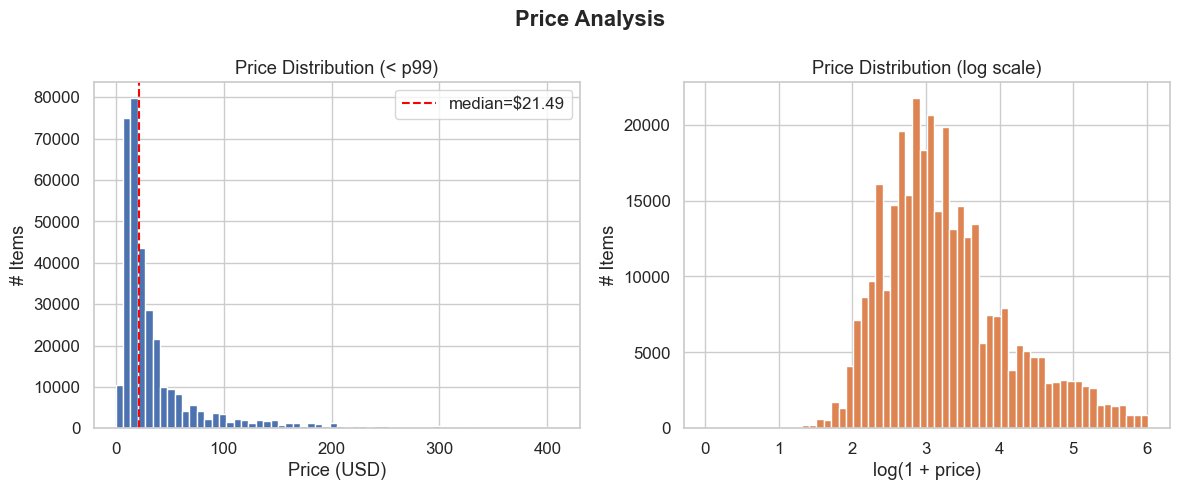

  Saved → D:\mmd\outputs\figures\06_price_distribution.png
Price bin distribution:
price_bin
<$10         50244
$10-25      147387
$25-50       77795
$50-100      34687
$100-200     20749
>$200        12298

Missing price: 324,117 (48.6%)


In [19]:
import re

# TIỀN XỬ LÝ DỮ LIỆU GIÁ (PRICE PARSING)
# Kiểm tra xem cột 'price_usd' đã tồn tại chưa, nếu chưa thì tiến hành bóc tách từ cột 'price' thô
if "price_usd" not in df_meta.columns:
    # Chỉ load thêm đúng cột 'price' dạng chuỗi (raw text) từ file Parquet lên bộ nhớ
    _price_raw = pd.read_parquet(META_FILE, columns=["item_idx", "price"], engine="pyarrow")["price"]
    
    def _parse_price(s):
        """
        Hàm xử lý chuỗi giá tiền bị bẩn (VD: "$12.99 - $15.99", "Price: $10.00").
        Sử dụng Regex để tìm tất cả các con số, sau đó tính trung bình nếu có khoảng giá (range).
        """
        if pd.isna(s) or str(s).strip() in ("", "None", "null"): 
            return float("nan")
            
        # Regex tìm các cụm số nguyên hoặc số thập phân (VD: 12, 12.99)
        nums = re.findall(r"[\d]+(?:\.[\d]+)?", str(s))
        
        # Nếu tìm thấy nhiều số (khoảng giá), lấy trung bình cộng. Nếu không trả về NaN.
        return round(sum(float(n) for n in nums) / len(nums), 2) if nums else float("nan")
        
    # Áp dụng hàm _parse_price cho toàn bộ cột và ép kiểu Float32 để tiết kiệm RAM
    df_meta["price_usd"] = _price_raw.apply(_parse_price).astype("float32")
    
    # Xóa biến phụ khỏi bộ nhớ và kích hoạt gom rác
    del _price_raw
    import gc; gc.collect()

# LỌC DỮ LIỆU (LOẠI BỎ OUTLIERS)
# Lọc bỏ giá trị NaN
price_valid = df_meta["price_usd"].dropna()

# Lọc bỏ các sản phẩm có giá <= 0 (lỗi dữ liệu) và 
# loại bỏ top 1% sản phẩm đắt nhất (Outliers/Whales) để biểu đồ không bị kéo giãn quá mức
price_valid = price_valid[(price_valid > 0) & (price_valid < price_valid.quantile(0.99))]

# VẼ BIỂU ĐỒ PHÂN BỐ GIÁ CẢ
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Biểu đồ 1: Histogram phân bố giá gốc (Đã loại outlier > p99)
axes[0].hist(price_valid, bins=60, color=COLOR_PRIMARY, edgecolor="white")
axes[0].set_title("Price Distribution (< p99)")
axes[0].set_xlabel("Price (USD)")
axes[0].set_ylabel("# Items")

# Thêm đường trung vị (Median) thay vì Trung bình (Mean) vì giá cả thường bị lệch phải (right-skewed)
axes[0].axvline(price_valid.median(), color="red", ls="--", lw=1.5,
                label=f"median=${price_valid.median():.2f}")
axes[0].legend()

# Biểu đồ 2: Histogram phân bố giá theo thang Log (Log Scale)
# Hàm log1p (log(1 + x)) giúp xử lý mượt mà các giá trị x gần 0, 
# đưa phân phối lệch (skewed) về gần dạng phân phối chuẩn (normal distribution) hơn
axes[1].hist(np.log1p(price_valid), bins=60, color=COLOR_SECONDARY, edgecolor="white")
axes[1].set_title("Price Distribution (log scale)")
axes[1].set_xlabel("log(1 + price)")
axes[1].set_ylabel("# Items")

plt.suptitle("Price Analysis", fontweight="bold")
savefig("06_price_distribution")

# FEATURE ENGINEERING: CHIA NHÓM GIÁ (PRICE BUCKETS)
# Phân chia giá thành các phân khúc rời rạc (categorical features) 
# giúp các mô hình Machine Learning/Deep Learning học nhóm khách hàng dễ hơn
price_bins  = [0, 10, 25, 50, 100, 200, float("inf")]
price_lbls  = ["<$10", "$10-25", "$25-50", "$50-100", "$100-200", ">$200"]

df_meta["price_bin"] = pd.cut(df_meta["price_usd"], bins=price_bins, labels=price_lbls)

# In kết quả thống kê phân nhóm
print("Price bin distribution:")
print(df_meta["price_bin"].value_counts().sort_index().to_string())

# In tỷ lệ sản phẩm bị thiếu dữ liệu giá (Missing data)
print(f"\nMissing price: {df_meta['price_usd'].isna().sum():,} "
      f"({df_meta['price_usd'].isna().mean()*100:.1f}%)")

## 8 · EDA Summary & Recommendations

In [20]:

# TÍNH TOÁN CÁC CHỈ SỐ TỔNG QUAN
# Đếm số lượng Users và Items duy nhất
n_users = sessions["user_idx"].nunique()
n_items = df["item_idx"].nunique()

# Tổng số lượt tương tác (Interactions)
n_inter = len(df)

# Tính toán các mốc phân vị (Percentile) của độ dài phiên (Session Length)
p50_seq = int(np.percentile(sessions["seq_len"], 50)) # Độ dài trung vị
p95_seq = int(np.percentile(sessions["seq_len"], 95)) # Bao phủ 95% lượng user

# IN BÁO CÁO TỔNG KẾT EDA
print("="*60)
print("  EDA SUMMARY")
print("="*60)
print(f"  Users             : {n_users:>10,}")
print(f"  Items             : {n_items:>10,}")
print(f"  Interactions      : {n_inter:>10,}")

# Độ thưa thớt (Sparsity) của ma trận User-Item
# Công thức: 1 - (Số tương tác thực tế / Tổng số tương tác có thể xảy ra)
# Sparsity càng gần 1 nghĩa là dữ liệu càng thưa, mô hình C.F. (Collaborative Filtering) truyền thống sẽ càng khó học
print(f"  Sparsity          : {1-n_inter/(n_users*n_items):.6f}")

print(f"  Avg seq len (p50) : {p50_seq:>10}")
print(f"  Avg seq len (p95) : {p95_seq:>10}")

# Kiểm tra an toàn xem biến cold_start_ratio đã được khởi tạo ở các cell trước chưa
_csr = cold_start_ratio if "cold_start_ratio" in dir() else float("nan")
print(f"  Cold-start ratio  : {_csr*100:>9.2f}%")
print("="*60)

# ĐỀ XUẤT THAM SỐ CHO HUẤN LUYỆN MÔ HÌNH
print("\n  RECOMMENDATIONS FOR MODELING")
print("-"*60)
# Kích thước cửa sổ trượt cho Item2Vec: Mức 5 thường hoạt động tốt nhất cho hành vi mua kèm (co-purchase)
print(f"  Item2Vec window_size : 5 (typical for co-purchase)")
print(f"  Item2Vec embedding   : 128")

# Đề xuất cắt/đệm chuỗi (Truncate/Padding) ở mốc p95 để tối ưu hóa bộ nhớ VRAM cho GPU
print(f"  GRU4Rec max_seq_len  : {p95_seq} (p95 of session length)")
print(f"  GRU4Rec hidden_size  : 256")

# Vì biểu đồ phân phối Item (ở cell trước) có dạng đuôi dài (long-tail), 
# ta cần áp dụng Popularity-based Negative Sampling để mô hình không bị thiên vị (bias) các item phổ biến.
print(f"  Negative sampling    : popularity-based (due to long-tail)")
print("="*60)

  EDA SUMMARY
  Users             :  2,712,338
  Items             :    667,277
  Interactions      : 24,930,015
  Sparsity          : 0.999986
  Avg seq len (p50) :          7
  Avg seq len (p95) :         21
  Cold-start ratio  :      0.29%

  RECOMMENDATIONS FOR MODELING
------------------------------------------------------------
  Item2Vec window_size : 5 (typical for co-purchase)
  Item2Vec embedding   : 128
  GRU4Rec max_seq_len  : 21 (p95 of session length)
  GRU4Rec hidden_size  : 256
  Negative sampling    : popularity-based (due to long-tail)
